### ADHD Classification model Experiments

In [ ]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from adhd_classifier.data_loader import load_data, subject_split, get_subject_windows, EEG_CHANNELS
from adhd_classifier.preprocessing import drop_missing, clip_artefacts
from adhd_classifier.feature_extraction import extract_subject_features, build_feature_names
from adhd_classifier.evaluation import evaluate, plot_confusion_matrix, plot_roc_curve, compare_models, aggregate_by_subject
from adhd_classifier.baseline import train_baselines, cross_validate_classifiers
from adhd_classifier.neural_net import ADHDNet, train_nn, EEGConvNet, train_cnn, prepare_cnn_input

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../../adhd_classifier/data/adhdata.csv'


Load and split data

In [ ]:
df = load_data(DATA_PATH)
df = drop_missing(df)
train_df, test_df = subject_split(df, test_size=0.2, random_state=42)
train_df, test_df = clip_artefacts(train_df, test_df, threshold=5.0)


Loaded 2,166,383 samples | 121 subjects (61 ADHD, 60 Control)
Train: 96 subjects (48 ADHD, 48 Control)
Test:  25 subjects (13 ADHD, 12 Control)


Feature extraction

In [ ]:
from sklearn.preprocessing import RobustScaler

print("extracting features from train set")
X_train, y_train, groups_train = extract_subject_features(train_df)
print("extracting features from test set")
X_test, y_test, groups_test = extract_subject_features(test_df)

feat_scaler = RobustScaler()
X_train = feat_scaler.fit_transform(X_train)
X_test  = feat_scaler.transform(X_test)

print("\nextracting raw windows for CNN")
X_train_raw, _, _ = get_subject_windows(train_df, window_size=256, step=128)
X_test_raw,  _, _ = get_subject_windows(test_df,  window_size=256, step=128)
X_train_cnn = prepare_cnn_input(X_train_raw)
X_test_cnn  = prepare_cnn_input(X_test_raw)

feature_names = build_feature_names()
print(f"\nfeature matrix:  train={X_train.shape}, test={X_test.shape}")
print(f"raw cnn windows: train={X_train_cnn.shape}, test={X_test_cnn.shape}")
print(f"total features:  {len(feature_names)}")
print(f"train class balance: {y_train.sum()} ADHD / {(y_train==0).sum()} Control")
print(f"test  class balance: {y_test.sum()} ADHD / {(y_test==0).sum()} Control")

_train_inner_df, _val_df = subject_split(train_df, test_size=0.2, random_state=0)

print("\nextracting inner-train / val features for neural net training")
X_train_inner, y_train_inner, _ = extract_subject_features(_train_inner_df)
X_val,         y_val,         _ = extract_subject_features(_val_df)
X_train_inner = feat_scaler.transform(X_train_inner)
X_val         = feat_scaler.transform(X_val)

_inner_raw, _, _ = get_subject_windows(_train_inner_df, window_size=256, step=128)
_val_raw,   _, _ = get_subject_windows(_val_df,         window_size=256, step=128)
X_train_cnn_inner = prepare_cnn_input(_inner_raw)
X_val_cnn         = prepare_cnn_input(_val_raw)

print(f"NN  inner-train: {X_train_inner.shape}  |  val: {X_val.shape}")
print(f"CNN inner-train: {X_train_cnn_inner.shape}  |  val: {X_val_cnn.shape}")


extracting features from train set
extracting features from test set

feature matrix: train=(96, 229), test=(25, 229)
total features: 229
train class balance: 48 ADHD / 48 Control
test  class balance: 13 ADHD / 12 Control


Feature importance preview

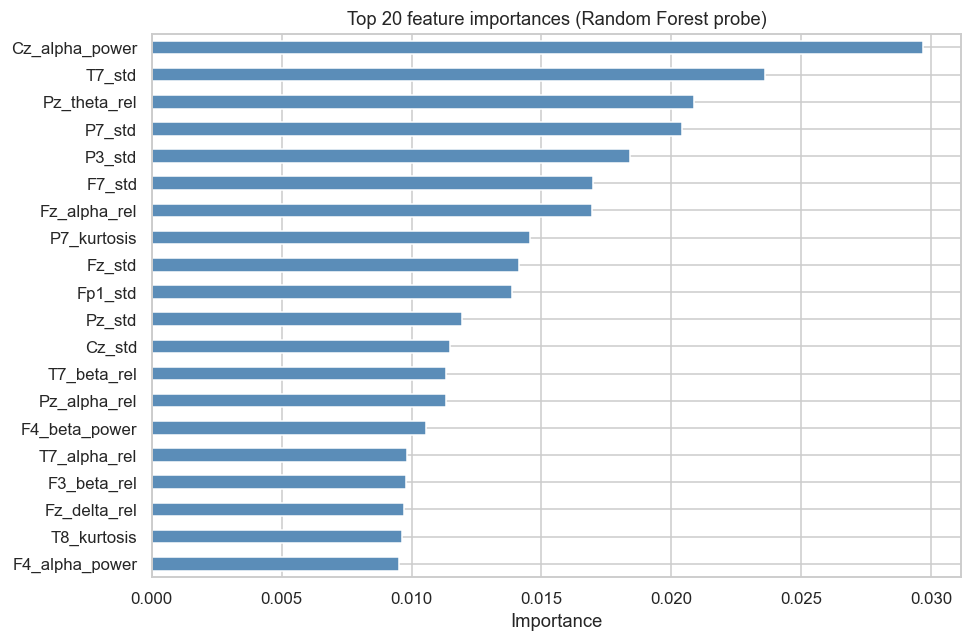

TAR feature rank: 182 / 229


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_probe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_probe.fit(X_train, y_train)

importances = pd.Series(rf_probe.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#5b8db8')
ax.set_title('Top 20 feature importances (Random Forest probe)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

tar_rank = importances.rank(ascending=False)['theta_alpha_ratio']
print(f"TAR feature rank: {int(tar_rank)} / {len(importances)}")

GroupKFold cross-validation on train set

In [ ]:
print("running 5-fold GroupKFold cross-validation")
cv_summary = cross_validate_classifiers(X_train, y_train, groups=groups_train, n_splits=5)

rows = []
for name, metrics in cv_summary.items():
    row = {'Model': name}
    for metric, (mean, std) in metrics.items():
        row[metric] = f"{mean:.3f} ± {std:.3f}"
    rows.append(row)

cv_df = pd.DataFrame(rows).set_index('Model')
print("\ncross-validation results:")
cv_df


running 5-fold GroupKFold cross-validation
Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

cross-validation results:


,accuracy,f1,roc_auc
Model,,,
SVM (RBF),0.655 ± 0.095,0.678 ± 0.103,0.747 ± 0.115
Random Forest,0.696 ± 0.110,0.695 ± 0.144,0.738 ± 0.061
Gradient Boosting,0.696 ± 0.114,0.691 ± 0.142,0.723 ± 0.066
LDA,0.573 ± 0.089,0.564 ± 0.130,0.534 ± 0.143


Train baselines on full train set

training baseline classifiers
Trained: SVM (RBF)
Trained: Random Forest
Trained: Gradient Boosting
Trained: LDA

SVM (RBF)
              precision    recall  f1-score   support

     Control       0.64      0.75      0.69        12
        ADHD       0.73      0.62      0.67        13

    accuracy                           0.68        25
   macro avg       0.69      0.68      0.68        25
weighted avg       0.69      0.68      0.68        25

ROC AUC: 0.5962


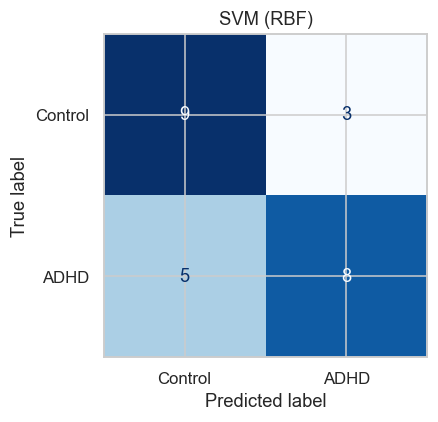


Random Forest
              precision    recall  f1-score   support

     Control       0.64      0.75      0.69        12
        ADHD       0.73      0.62      0.67        13

    accuracy                           0.68        25
   macro avg       0.69      0.68      0.68        25
weighted avg       0.69      0.68      0.68        25

ROC AUC: 0.6442


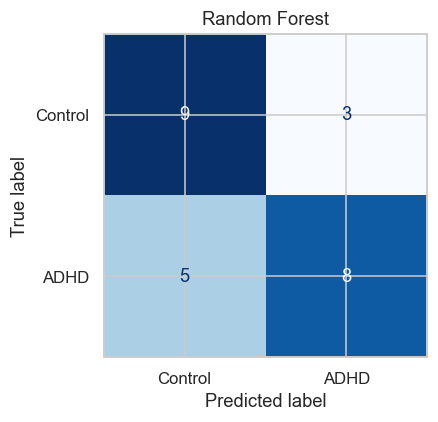


Gradient Boosting
              precision    recall  f1-score   support

     Control       0.58      0.58      0.58        12
        ADHD       0.62      0.62      0.62        13

    accuracy                           0.60        25
   macro avg       0.60      0.60      0.60        25
weighted avg       0.60      0.60      0.60        25

ROC AUC: 0.6603


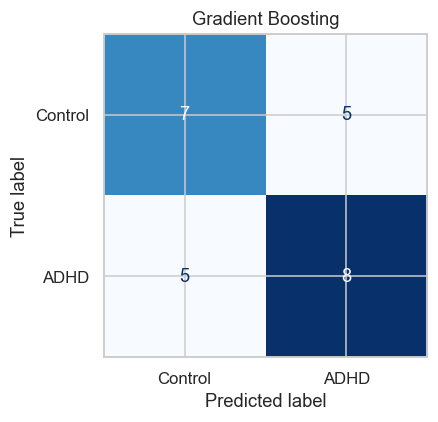


LDA
              precision    recall  f1-score   support

     Control       0.50      0.50      0.50        12
        ADHD       0.54      0.54      0.54        13

    accuracy                           0.52        25
   macro avg       0.52      0.52      0.52        25
weighted avg       0.52      0.52      0.52        25

ROC AUC: 0.4359


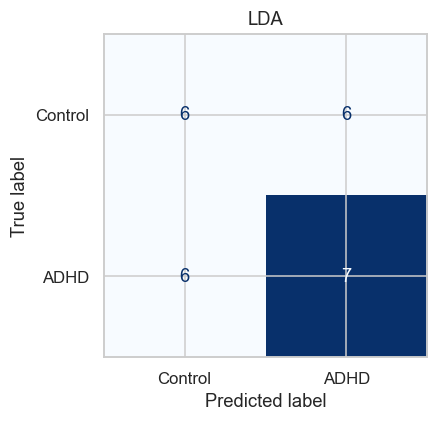

In [ ]:
print("training baseline classifiers")
baseline_results = train_baselines(X_train, y_train, X_test, y_test)

all_metrics = {}

for name, res in baseline_results.items():
    print(f"\n{'='*40}\n{name}")
    print("window-level:")
    evaluate(y_test, res['y_pred'], res['y_proba'])
    agg_true, agg_pred, agg_proba = aggregate_by_subject(y_test, res['y_pred'], groups_test, res['y_proba'])
    print("subject-level:")
    metrics = evaluate(agg_true, agg_pred, agg_proba)
    all_metrics[name] = metrics
    res['agg_true'], res['agg_pred'], res['agg_proba'] = agg_true, agg_pred, agg_proba
    plot_confusion_matrix(agg_true, agg_pred, title=f"{name} (subject-level)")


ROC curves all baselines

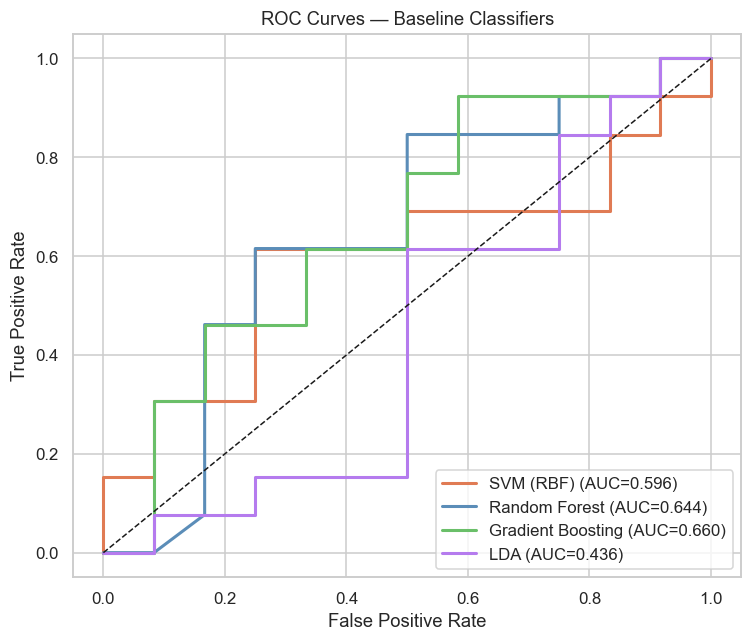

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#e07b54', '#5b8db8', '#6abf69', '#b57bee']
for (name, res), color in zip(baseline_results.items(), colors):
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc = roc_auc_score(y_test, res['y_proba'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Baseline Classifiers')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Neural network MLP

In [ ]:
import torch

nn_configs = [
    {'hidden_dims': [128, 64],        'dropout': 0.3, 'label': 'MLP-small (128-64, d=0.3)'},
    {'hidden_dims': [256, 128, 64],   'dropout': 0.3, 'label': 'MLP-medium (256-128-64, d=0.3)'},
    {'hidden_dims': [256, 128, 64],   'dropout': 0.5, 'label': 'MLP-medium (256-128-64, d=0.5)'},
]

nn_results = {}

for cfg in nn_configs:
    print(f"\ntraining {cfg['label']}")
    model, history = train_nn(
        X_train_inner, y_train_inner, X_val, y_val,
        hidden_dims=cfg['hidden_dims'],
        dropout=cfg['dropout'],
        epochs=60,
        lr=1e-3,
        batch_size=32,
    )
    model.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_test, dtype=torch.float32)
        logits = model(X_te_t)
        proba = torch.sigmoid(logits).numpy()
        preds = (proba > 0.5).astype(int)

    nn_results[cfg['label']] = {
        'model': model,
        'history': history,
        'y_pred': preds,
        'y_proba': proba,
    }



training MLP-small (128-64, d=0.3)
epoch  10 | train_loss=0.5404 | val_loss=0.6208 | val_acc=0.6000
epoch  20 | train_loss=0.4579 | val_loss=0.6119 | val_acc=0.6000
epoch  30 | train_loss=0.3508 | val_loss=0.5698 | val_acc=0.6000
epoch  40 | train_loss=0.2754 | val_loss=0.5218 | val_acc=0.6800
epoch  50 | train_loss=0.1630 | val_loss=0.5979 | val_acc=0.6800
epoch  60 | train_loss=0.1442 | val_loss=0.7558 | val_acc=0.6800

training MLP-medium (256-128-64, d=0.3)
epoch  10 | train_loss=0.5190 | val_loss=0.6283 | val_acc=0.5200
epoch  20 | train_loss=0.4055 | val_loss=0.5592 | val_acc=0.6000
epoch  30 | train_loss=0.2474 | val_loss=0.5778 | val_acc=0.6800
epoch  40 | train_loss=0.1755 | val_loss=0.6533 | val_acc=0.7200
epoch  50 | train_loss=0.1289 | val_loss=0.7507 | val_acc=0.6800
epoch  60 | train_loss=0.0951 | val_loss=0.9066 | val_acc=0.7200

training MLP-medium (256-128-64, d=0.5)
epoch  10 | train_loss=0.6371 | val_loss=0.6809 | val_acc=0.5600
epoch  20 | train_loss=0.6029 | val_l

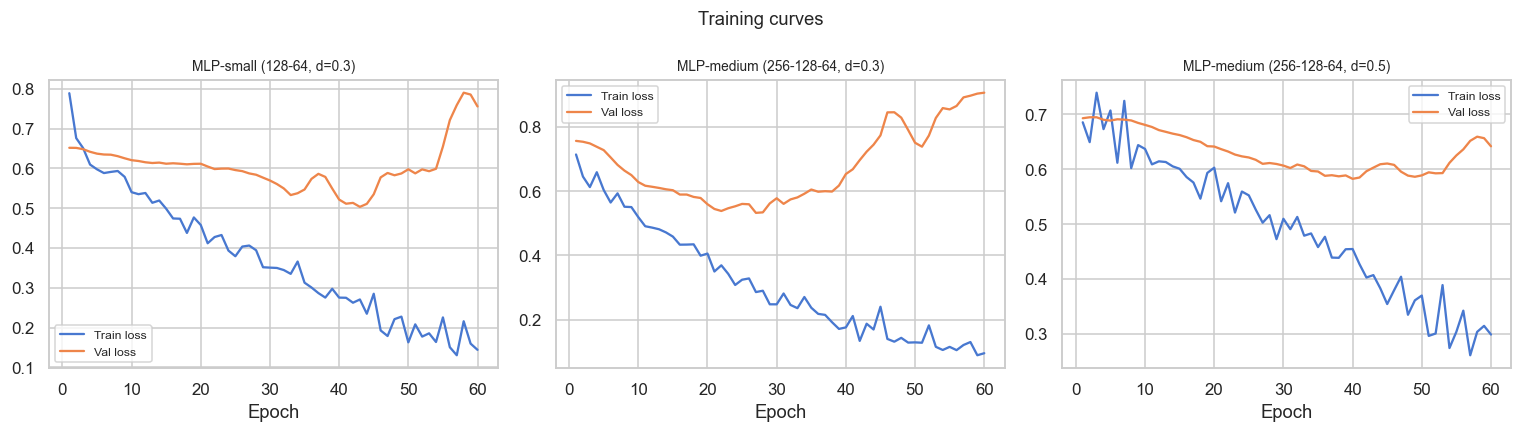

In [ ]:
fig, axes = plt.subplots(1, len(nn_configs), figsize=(14, 4), sharey=False)

for ax, cfg in zip(axes, nn_configs):
    hist = nn_results[cfg['label']]['history']
    epochs_range = [h['epoch'] for h in hist]
    ax.plot(epochs_range, [h['train_loss'] for h in hist], label='Train loss')
    ax.plot(epochs_range, [h['val_loss'] for h in hist], label='Val loss')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

plt.suptitle('Training curves', fontsize=12)
plt.tight_layout()
plt.show()


MLP-small (128-64, d=0.3)
              precision    recall  f1-score   support

     Control       0.62      0.83      0.71        12
        ADHD       0.78      0.54      0.64        13

    accuracy                           0.68        25
   macro avg       0.70      0.69      0.68        25
weighted avg       0.70      0.68      0.67        25

ROC AUC: 0.7372


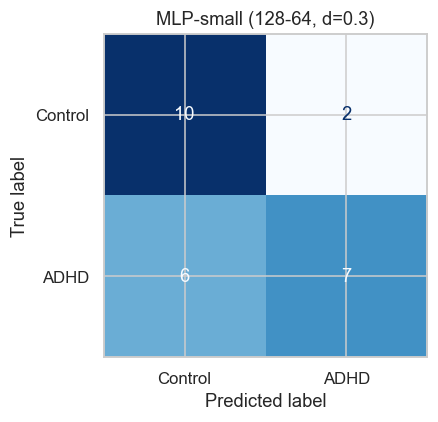


MLP-medium (256-128-64, d=0.3)
              precision    recall  f1-score   support

     Control       0.73      0.67      0.70        12
        ADHD       0.71      0.77      0.74        13

    accuracy                           0.72        25
   macro avg       0.72      0.72      0.72        25
weighted avg       0.72      0.72      0.72        25

ROC AUC: 0.7436


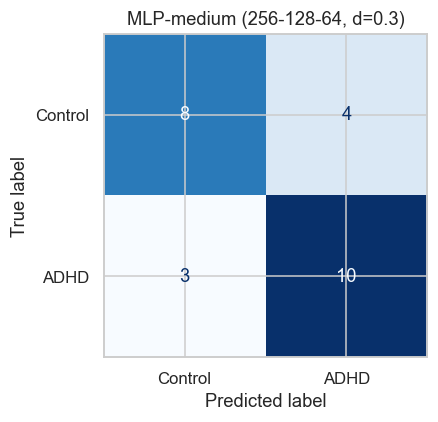


MLP-medium (256-128-64, d=0.5)
              precision    recall  f1-score   support

     Control       0.64      0.75      0.69        12
        ADHD       0.73      0.62      0.67        13

    accuracy                           0.68        25
   macro avg       0.69      0.68      0.68        25
weighted avg       0.69      0.68      0.68        25

ROC AUC: 0.7436


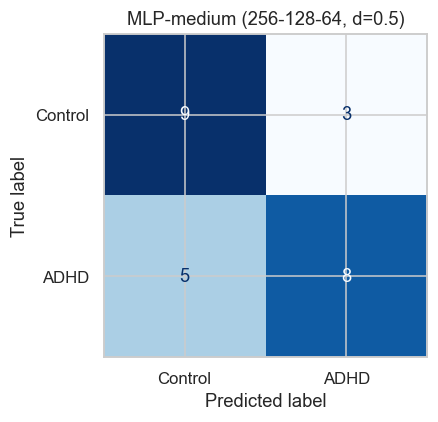

In [ ]:
for name, res in nn_results.items():
    print(f"\n{'='*40}\n{name}")
    print("window-level:")
    evaluate(y_test, res['y_pred'], res['y_proba'])
    agg_true, agg_pred, agg_proba = aggregate_by_subject(y_test, res['y_pred'], groups_test, res['y_proba'])
    print("subject-level:")
    metrics = evaluate(agg_true, agg_pred, agg_proba)
    all_metrics[name] = metrics
    res['agg_true'], res['agg_pred'], res['agg_proba'] = agg_true, agg_pred, agg_proba
    plot_confusion_matrix(agg_true, agg_pred, title=f"{name} (subject-level)")


1D-CNN on raw EEG windows

In [ ]:
import torch

cnn_configs = [
    {'dropout': 0.3, 'label': 'CNN (dropout=0.3)'},
    {'dropout': 0.5, 'label': 'CNN (dropout=0.5)'},
]

cnn_results = {}

for cfg in cnn_configs:
    print(f"\ntraining {cfg['label']}")
    model, history = train_cnn(
        X_train_cnn_inner, y_train_inner,
        X_val_cnn,         y_val,
        n_channels=len(EEG_CHANNELS),
        dropout=cfg['dropout'],
        epochs=50,
        lr=1e-3,
        batch_size=64,
    )
    model.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_test_cnn, dtype=torch.float32)
        logits = model(X_te_t)
        proba = torch.sigmoid(logits).numpy()
        preds = (proba > 0.5).astype(int)

    cnn_results[cfg['label']] = {
        'model': model,
        'history': history,
        'y_pred': preds,
        'y_proba': proba,
    }


In [ ]:
fig, axes = plt.subplots(1, len(cnn_configs), figsize=(10, 4), sharey=False)

for ax, cfg in zip(axes, cnn_configs):
    hist = cnn_results[cfg['label']]['history']
    ax.plot([h['epoch'] for h in hist], [h['train_loss'] for h in hist], label='Train loss')
    ax.plot([h['epoch'] for h in hist], [h['val_loss']   for h in hist], label='Val loss')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

plt.suptitle('CNN training curves', fontsize=12)
plt.tight_layout()
plt.show()

for name, res in cnn_results.items():
    print(f"\n{'='*40}\n{name}")
    print("window-level:")
    evaluate(y_test, res['y_pred'], res['y_proba'])
    agg_true, agg_pred, agg_proba = aggregate_by_subject(y_test, res['y_pred'], groups_test, res['y_proba'])
    print("subject-level:")
    metrics = evaluate(agg_true, agg_pred, agg_proba)
    all_metrics[name] = metrics
    res['agg_true'], res['agg_pred'], res['agg_proba'] = agg_true, agg_pred, agg_proba
    plot_confusion_matrix(agg_true, agg_pred, title=f"{name} (subject-level)")


Final model comparison


Model Comparison:
                                accuracy  f1_adhd  precision_adhd  recall_adhd  roc_auc
SVM (RBF)                           0.68   0.6667          0.7273       0.6154   0.5962
Random Forest                       0.68   0.6667          0.7273       0.6154   0.6442
Gradient Boosting                   0.60   0.6154          0.6154       0.6154   0.6603
LDA                                 0.52   0.5385          0.5385       0.5385   0.4359
MLP-small (128-64, d=0.3)           0.68   0.6364          0.7778       0.5385   0.7372
MLP-medium (256-128-64, d=0.3)      0.72   0.7407          0.7143       0.7692   0.7436
MLP-medium (256-128-64, d=0.5)      0.68   0.6667          0.7273       0.6154   0.7436


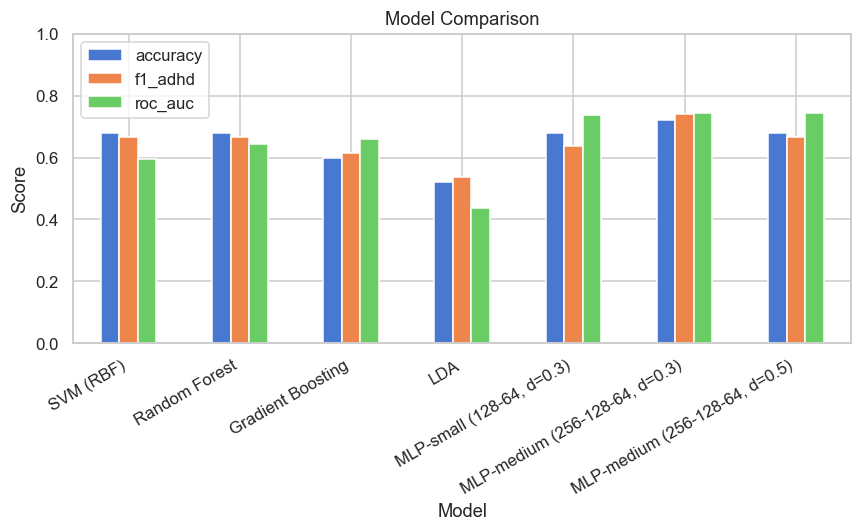

In [ ]:
compare_models(all_metrics)

C:\Users\kamil\AppData\Local\Temp\ipykernel_37792\270317826.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(all_results))


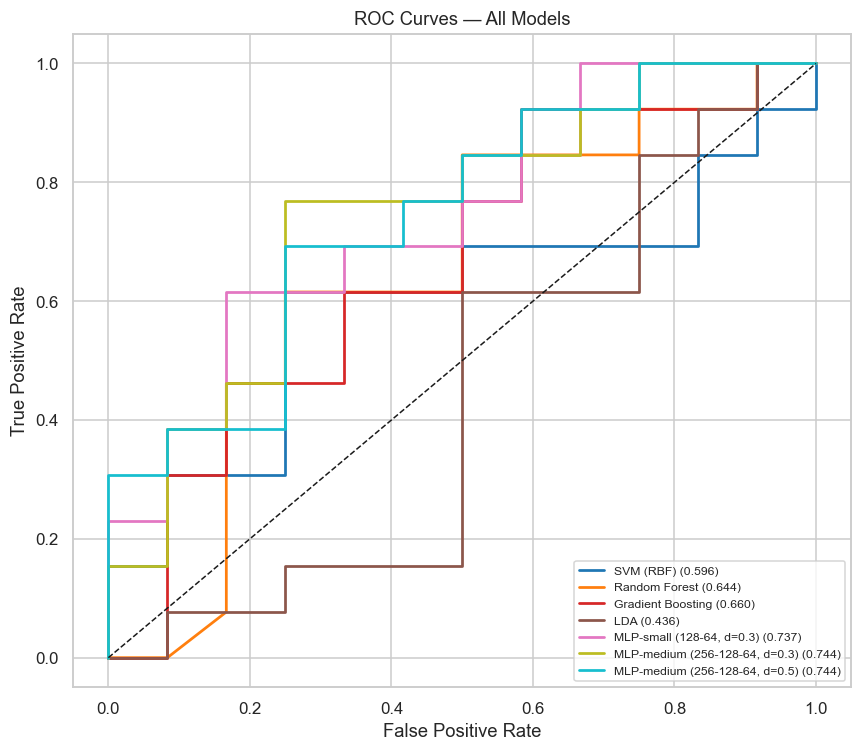

In [ ]:
import matplotlib
from sklearn.metrics import roc_curve, roc_auc_score

all_results = {**baseline_results, **{k: v for k, v in nn_results.items()}, **{k: v for k, v in cnn_results.items()}}

fig, ax = plt.subplots(figsize=(9, 7))
cmap = matplotlib.colormaps['tab10'].resampled(len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    proba = res.get('agg_proba', res['y_proba'])
    true  = res.get('agg_true',  y_test)
    if proba is not None:
        fpr, tpr, _ = roc_curve(true, proba)
        auc = roc_auc_score(true, proba)
        ax.plot(fpr, tpr, label=f"{name} ({auc:.3f})", color=cmap(i), linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (subject-level)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()
